# Dual-branch teacher retrain + knowledge distillation

> **Intended environment: Google Colab.** This notebook uses Colab-only APIs (`google.colab.files.download`, `google.colab.runtime.unassign`). To run locally or in vanilla Jupyter, skip or remove those cells.
> **Recommended Colab GPU runtimes:** **A100**, **L4**, or **H100** (**Runtime → Change runtime type → GPU**).

This notebook **retrains** `DualBranchDeepfakeNet` (MaxViT-Tiny RGB + FFT spectral CNN) on DeepDetect-2025, **saves** `final_dual_maxvit.pt`, then **distills** into a smaller **RGB-only** student (`mobilenetv3_small_100` by default).

> **Requirements**
> - Defaults assume **batch size 64** at **224×224**; shrink batch if you hit GPU memory limits.
> - **Mixed precision (AMP):** uses **bfloat16** when supported (**Ampere** and newer); otherwise training falls back to **float16** autocast.
> - **Data:** multi‑GB download; set **`DF_DATA_ROOT`** if `kagglehub` fails.

Distillation loss: $\alpha \cdot \mathrm{CE}(y) + (1-\alpha) \cdot T^2 \mathrm{KL}(p_T^{teacher} \| q_T^{student})$.


In [1]:
# Install dependencies (Colab-safe pins)
!pip install -q --upgrade "timm>=1.0,<2" "albumentations>=1.4,<2" opencv-python-headless kagglehub scikit-learn tqdm matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.9/274.9 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 196.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 243.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 30.5 MB/s eta 0:00:00


In [2]:
import os, sys, math, time, json, random, gc
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve

import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("bf16:", torch.cuda.is_bf16_supported())


/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
bf16: True


In [3]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


set_seed()


class CFG:
    num_workers = 2 if os.name == "nt" else 4
    use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()


# Output directory: Colab vs local
if Path("/content").exists():
    OUT_DIR = Path(os.environ.get("DF_OUT_DIR", "/content/outputs"))
else:
    OUT_DIR = Path(os.environ.get("DF_OUT_DIR", "./outputs"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR.resolve())


OUT_DIR: /content/outputs


In [4]:
# Dataset download (Kaggle DeepDetect-2025)
DATA_ROOT = os.environ.get("DF_DATA_ROOT")
if DATA_ROOT:
    DATA_ROOT = Path(DATA_ROOT)
    print("Using DF_DATA_ROOT:", DATA_ROOT)
else:
    try:
        import kagglehub

        DATA_ROOT = Path(kagglehub.dataset_download("ayushmandatta1/deepdetect-2025"))
        print("Downloaded via kagglehub:", DATA_ROOT)
    except Exception as e:
        print("kagglehub failed:", e)
        print("Set env DF_DATA_ROOT to your dataset folder and re-run this cell.")
        DATA_ROOT = None


Using Colab cache for faster access to the 'deepdetect-2025' dataset.
Downloaded via kagglehub: /kaggle/input/deepdetect-2025


In [5]:
import re


def build_index(root: Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    real_dirs = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() in {"real", "real_images", "authentic", "0_real"}
    ]
    fake_dirs = [
        p for p in root.rglob("*")
        if p.is_dir() and p.name.lower() in {"fake", "fake_images", "manipulated", "deepfake", "1_fake"}
    ]

    for d in real_dirs:
        for img in list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg")):
            split = "train"
            for part in img.parts:
                if part.lower() in {"train", "test", "valid", "val"}:
                    split = "val" if part.lower() in {"val", "valid"} else part.lower()
                    break
            rows.append({"filepath": str(img), "label": 0, "split": split})
    for d in fake_dirs:
        for img in list(d.glob("*.jpg")) + list(d.glob("*.png")) + list(d.glob("*.jpeg")):
            split = "train"
            for part in img.parts:
                if part.lower() in {"train", "test", "valid", "val"}:
                    split = "val" if part.lower() in {"val", "valid"} else part.lower()
                    break
            rows.append({"filepath": str(img), "label": 1, "split": split})

    if not rows:
        csvs = list(root.rglob("*.csv"))
        for csv_path in csvs:
            try:
                df_csv = pd.read_csv(csv_path)
                fn_col = next((c for c in df_csv.columns if re.search(r"file|image|path|name", c, re.I)), None)
                lab_col = next((c for c in df_csv.columns if re.search(r"label|class|target|fake", c, re.I)), None)
                if fn_col and lab_col:
                    for _, r in df_csv.iterrows():
                        candidate = (csv_path.parent / str(r[fn_col])).resolve()
                        if not candidate.exists():
                            candidate = (root / str(r[fn_col])).resolve()
                        if candidate.exists():
                            lab = r[lab_col]
                            if isinstance(lab, str):
                                lab = 1 if "fake" in lab.lower() else 0
                            else:
                                lab = int(lab)
                            rows.append({"filepath": str(candidate), "label": lab, "split": "train"})
                    if rows:
                        break
            except Exception:
                continue

    return pd.DataFrame(rows)


assert DATA_ROOT is not None, "Set DATA_ROOT / DF_DATA_ROOT first."
df = build_index(DATA_ROOT)
print(f"Indexed {len(df):,} images.")
print(df["label"].value_counts().rename({0: "real", 1: "fake"}))

if "split" not in df.columns or df["split"].nunique() == 1:
    train_df, val_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=SEED)
else:
    train_df = df[df["split"] == "train"].reset_index(drop=True)
    val_df = df[df["split"].isin(["val", "test"])].reset_index(drop=True)

print(f"train: {len(train_df):,}  |  val: {len(val_df):,}")


Indexed 112,185 images.
label
real    60192
fake    51993
Name: count, dtype: int64
train: 90,409  |  val: 21,776


In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def make_transforms(img_size: int, heavy: bool = True):
    if heavy:
        train_tf = A.Compose(
            [
                A.Resize(int(img_size * 1.1), int(img_size * 1.1)),
                A.RandomResizedCrop(size=(img_size, img_size), scale=(0.7, 1.0), ratio=(0.85, 1.18)),
                A.HorizontalFlip(p=0.5),
                A.OneOf(
                    [
                        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15),
                        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=10),
                        A.CLAHE(clip_limit=2.0),
                    ],
                    p=0.5,
                ),
                A.OneOf(
                    [
                        A.GaussianBlur(blur_limit=(3, 5)),
                        A.MotionBlur(blur_limit=5),
                        A.ImageCompression(quality_range=(55, 95)),
                    ],
                    p=0.4,
                ),
                A.CoarseDropout(
                    num_holes_range=(1, 4),
                    hole_height_range=(8, max(8, img_size // 8)),
                    hole_width_range=(8, max(8, img_size // 8)),
                    p=0.25,
                ),
                A.Normalize(IMAGENET_MEAN, IMAGENET_STD),
                ToTensorV2(),
            ]
        )
    else:
        train_tf = A.Compose(
            [
                A.Resize(img_size, img_size),
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(p=0.3),
                A.Normalize(IMAGENET_MEAN, IMAGENET_STD),
                ToTensorV2(),
            ]
        )

    val_tf = A.Compose([A.Resize(img_size, img_size), A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
    return train_tf, val_tf


class DualBranchDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None, fft_size: int = 128, img_fallback_size: int = 224):
        self.paths = df["filepath"].tolist()
        self.labels = df["label"].astype(np.int64).tolist()
        self.transform = transform
        self.fft_size = fft_size
        self.img_fallback_size = img_fallback_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((self.img_fallback_size, self.img_fallback_size, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        rgb = (
            self.transform(image=img)["image"]
            if self.transform
            else torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        )

        gray = cv2.cvtColor(cv2.resize(img, (self.fft_size, self.fft_size)), cv2.COLOR_RGB2GRAY).astype(np.float32)
        f = np.fft.fftshift(np.fft.fft2(gray))
        log_mag = np.log1p(np.abs(f)).astype(np.float32)
        angle = np.angle(f).astype(np.float32)
        log_mag = log_mag / (log_mag.max() + 1e-6)
        angle = angle / np.pi
        spec = torch.from_numpy(np.stack([log_mag, angle], axis=0))

        return (rgb, spec), self.labels[idx]


def make_dual_loaders(train_df, val_df, img_size=224, batch_size=64):
    train_tf, val_tf = make_transforms(img_size, heavy=True)
    train_ds = DualBranchDataset(train_df, transform=train_tf, img_fallback_size=img_size)
    val_ds = DualBranchDataset(val_df, transform=val_tf, img_fallback_size=img_size)

    counts = train_df["label"].value_counts().to_dict()
    weights = train_df["label"].map(lambda y: 1.0 / counts[y]).values
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    nw = CFG.num_workers
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=nw,
        pin_memory=True,
        persistent_workers=(nw > 0),
        prefetch_factor=4 if nw > 0 else None,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size * 2,
        shuffle=False,
        num_workers=nw,
        pin_memory=True,
        persistent_workers=(nw > 0),
    )
    return train_loader, val_loader


In [15]:
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        import copy

        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                v.copy_(msd[k])


class SpectralCNN(nn.Module):
    def __init__(self, in_ch: int = 2, out_dim: int = 256):
        super().__init__()

        def block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc),
                nn.GELU(),
                nn.MaxPool2d(2),
            )

        self.b1 = block(in_ch, 32)
        self.b2 = block(32, 64)
        self.b3 = block(64, 128)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, out_dim), nn.GELU())

    def forward(self, x):
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        return self.head(x)


class DualBranchDeepfakeNet(nn.Module):
    def __init__(
        self,
        rgb_backbone: str = "maxvit_tiny_tf_224.in1k",
        num_classes: int = 2,
        spec_dim: int = 256,
        dropout: float = 0.2,
        img_size: int = 224,
    ):
        super().__init__()
        self.rgb = timm.create_model(
            rgb_backbone,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
            img_size=img_size,
        )
        rgb_dim = self.rgb.num_features
        self.spec = SpectralCNN(in_ch=2, out_dim=spec_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(rgb_dim + spec_dim),
            nn.Dropout(dropout),
            nn.Linear(rgb_dim + spec_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        rgb_x, spec_x = x
        f_rgb = self.rgb(rgb_x)
        f_spec = self.spec(spec_x)
        f = torch.cat([f_rgb, f_spec], dim=1)
        return self.head(f)


class StudentDeepfakeNet(nn.Module):
    def __init__(
        self,
        backbone: str = "mobilenetv3_small_100",
        num_classes: int = 2,
        dropout: float = 0.3,
        img_size: int = 224,
    ):
        super().__init__()
        # Many CNN backbones (e.g. MobileNet) don't accept `img_size`; ViT-style models often do.
        _kw = dict(pretrained=True, num_classes=0, global_pool="avg")
        try:
            self.backbone = timm.create_model(backbone, **{**_kw, "img_size": img_size})
        except TypeError:
            self.backbone = timm.create_model(backbone, **_kw)
        # `num_features` can disagree with actual pooled output for some timm versions / backbones.
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            feat = self.backbone(dummy)
            if feat.dim() == 4:
                feat = F.adaptive_avg_pool2d(feat, 1).flatten(1)
            elif feat.dim() > 2:
                feat = feat.flatten(1)
            d = int(feat.shape[-1])
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, num_classes))

    def forward(self, x):
        return self.head(self.backbone(x))


In [16]:
def evaluate_dual(model, loader, device=DEVICE):
    model.eval()
    all_logits, all_labels = [], []
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16
    with torch.no_grad():
        for (rgb, spec), yb in loader:
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            spec = spec.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
                logits = model((rgb, spec))
            all_logits.append(logits.float().cpu())
            all_labels.append(yb.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    y = labels.numpy()
    return {
        "acc": accuracy_score(y, preds),
        "auc": roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float("nan"),
        "f1": f1_score(y, preds),
        "cm": confusion_matrix(y, preds),
    }


def train_dual(
    model,
    train_loader,
    val_loader,
    *,
    epochs,
    lr=2e-4,
    weight_decay=5e-4,
    label_smoothing=0.1,
    use_ema=True,
    warmup_frac=0.05,
    run_name="dual",
):
    device = DEVICE
    model = model.to(device, memory_format=torch.channels_last)
    ema = ModelEMA(model) if use_ema else None
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
        fused=torch.cuda.is_available(),
    )
    total_steps = epochs * len(train_loader)
    warmup_steps = max(1, int(warmup_frac * total_steps))

    def lr_lambda(s):
        if s < warmup_steps:
            return s / warmup_steps
        p = (s - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * p))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16

    history = {"train_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}
    best_auc, best_state = -1.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        running, seen = 0.0, 0
        for (rgb, spec), yb in train_loader:
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            spec = spec.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
                logits = model((rgb, spec))
                loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            if ema is not None:
                ema.update(model)
            running += loss.item() * rgb.size(0)
            seen += rgb.size(0)

        train_loss = running / max(1, seen)
        eval_model = ema.module if ema is not None else model
        val = evaluate_dual(eval_model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val["acc"])
        history["val_auc"].append(val["auc"])
        history["val_f1"].append(val["f1"])
        print(
            f"[{run_name}] ep {epoch}/{epochs} | loss {train_loss:.4f} | "
            f"val acc {val['acc']:.4f} auc {val['auc']:.4f} f1 {val['f1']:.4f} | {time.time()-t0:.1f}s"
        )
        if val["auc"] > best_auc:
            best_auc = val["auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in eval_model.state_dict().items()}

    return {"history": history, "best_state": best_state, "best_auc": best_auc, "final_val": val}


## 1) Train teacher (dual-branch MaxViT)

Defaults match the tuned **winner** from the main pipeline (`img_size=224`, `dropout=0.4`, typical `lr`/`wd`). Override via env vars `TEACHER_LR`, `TEACHER_WD`, `TEACHER_EPOCHS`, `TEACHER_BATCH`.


In [24]:
RGB_BACKBONE = "maxvit_tiny_tf_224.in1k"
TEACHER_IMG_SIZE = 224
TEACHER_DROPOUT = 0.4
TEACHER_LR = float(os.environ.get("TEACHER_LR", "1.5e-4"))
TEACHER_WD = float(os.environ.get("TEACHER_WD", "5e-4"))
TEACHER_EPOCHS = int(os.environ.get("TEACHER_EPOCHS", "12"))
TEACHER_BATCH = int(os.environ.get("TEACHER_BATCH", "64"))

set_seed()
dual_train, dual_val = make_dual_loaders(train_df, val_df, img_size=TEACHER_IMG_SIZE, batch_size=TEACHER_BATCH)
teacher = DualBranchDeepfakeNet(
    rgb_backbone=RGB_BACKBONE,
    dropout=TEACHER_DROPOUT,
    img_size=TEACHER_IMG_SIZE,
)

teacher_out = train_dual(
    teacher,
    dual_train,
    dual_val,
    epochs=TEACHER_EPOCHS,
    lr=TEACHER_LR,
    weight_decay=TEACHER_WD,
    label_smoothing=0.1,
    run_name="teacher_dual_maxvit",
)

teacher_ckpt = OUT_DIR / "final_dual_maxvit.pt"
torch.save(
    {
        "state_dict": teacher_out["best_state"],
        "config": {
            "img_size": TEACHER_IMG_SIZE,
            "dropout": TEACHER_DROPOUT,
            "lr": TEACHER_LR,
            "wd": TEACHER_WD,
            "rgb_backbone": RGB_BACKBONE,
        },
        "val_metrics": {k: teacher_out["final_val"][k] for k in ("acc", "auc", "f1")},
    },
    teacher_ckpt,
)
print("Saved teacher ->", teacher_ckpt.resolve())
print("Teacher best val AUC:", teacher_out["best_auc"])

del teacher
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


[teacher_dual_maxvit] ep 1/12 | loss 0.3210 | val acc 0.7828 auc 0.9877 f1 0.8140 | 181.5s
[teacher_dual_maxvit] ep 2/12 | loss 0.2273 | val acc 0.9145 auc 0.9974 f1 0.9178 | 128.8s
[teacher_dual_maxvit] ep 3/12 | loss 0.2172 | val acc 0.9309 auc 0.9977 f1 0.9326 | 129.2s
[teacher_dual_maxvit] ep 4/12 | loss 0.2114 | val acc 0.9323 auc 0.9972 f1 0.9338 | 128.8s
[teacher_dual_maxvit] ep 5/12 | loss 0.2078 | val acc 0.9247 auc 0.9943 f1 0.9269 | 129.1s
[teacher_dual_maxvit] ep 6/12 | loss 0.2053 | val acc 0.9288 auc 0.9940 f1 0.9306 | 128.9s
[teacher_dual_maxvit] ep 7/12 | loss 0.2047 | val acc 0.9254 auc 0.9853 f1 0.9276 | 129.3s
[teacher_dual_maxvit] ep 8/12 | loss 0.2023 | val acc 0.9224 auc 0.9813 f1 0.9248 | 129.4s
[teacher_dual_maxvit] ep 9/12 | loss 0.2018 | val acc 0.9228 auc 0.9726 f1 0.9252 | 129.0s
[teacher_dual_maxvit] ep 10/12 | loss 0.2007 | val acc 0.9246 auc 0.9800 f1 0.9268 | 129.0s
[teacher_dual_maxvit] ep 11/12 | loss 0.2006 | val acc 0.9257 auc 0.9820 f1 0.9278 | 129.

In [25]:
# Download teacher model to local machine
from google.colab import files
files.download(teacher_ckpt.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# import torch
# from pathlib import Path

# teacher_ckpt = "final_dual_maxvit.pt"

# # PyTorch 2.6+ defaults weights_only=True for safety; checkpoints with dict+config need weights_only=False
# try:
#     ckpt = torch.load(teacher_ckpt, map_location="cpu", weights_only=False)
# except TypeError:
#     ckpt = torch.load(teacher_ckpt, map_location="cpu")

# teacher = DualBranchDeepfakeNet(
#     rgb_backbone=ckpt["config"]["rgb_backbone"],
#     dropout=ckpt["config"]["dropout"],
#     img_size=ckpt["config"]["img_size"],
# ).to(DEVICE, memory_format=torch.channels_last)

# teacher.load_state_dict(ckpt["state_dict"])
# teacher.eval()

## 2) Distill to RGB student

Student sees **only RGB**; teacher uses RGB+FFT. Tunables: `DISTILL_EPOCHS`, `DISTILL_LR`, `DISTILL_TEMP`, `DISTILL_ALPHA`, `STUDENT_BACKBONE`.


In [27]:
def evaluate_student(model, loader, device=DEVICE):
    model.eval()
    all_logits, all_labels = [], []
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16
    with torch.no_grad():
        for (rgb, _), yb in loader:
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            yb = yb.to(device, non_blocking=True)
            with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
                logits = model(rgb)
            all_logits.append(logits.float().cpu())
            all_labels.append(yb.cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    y = labels.numpy()
    return {
        "acc": accuracy_score(y, preds),
        "auc": roc_auc_score(y, probs) if len(np.unique(y)) > 1 else float("nan"),
        "f1": f1_score(y, preds),
    }


def train_distillation(
    teacher: DualBranchDeepfakeNet,
    student: StudentDeepfakeNet,
    train_loader,
    val_loader,
    *,
    epochs: int,
    lr: float,
    weight_decay: float,
    temperature: float = 4.0,
    alpha: float = 0.5,
    label_smoothing: float = 0.05,
    run_name: str = "distill",
):
    device = DEVICE
    teacher = teacher.to(device, memory_format=torch.channels_last).eval()
    for p in teacher.parameters():
        p.requires_grad_(False)

    student = student.to(device, memory_format=torch.channels_last)
    optimizer = torch.optim.AdamW(
        student.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999),
        fused=torch.cuda.is_available(),
    )
    total_steps = epochs * len(train_loader)
    warmup_steps = max(1, int(0.05 * total_steps))

    def lr_lambda(s):
        if s < warmup_steps:
            return s / warmup_steps
        p = (s - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * p))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    kl_loss_fn = nn.KLDivLoss(reduction="batchmean")
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16

    best_auc, best_state = -1.0, None
    history = {"train_loss": [], "val_acc": [], "val_auc": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        student.train()
        running, seen = 0.0, 0
        t0 = time.time()
        for (rgb, spec), yb in train_loader:
            rgb = rgb.to(device, non_blocking=True, memory_format=torch.channels_last)
            spec = spec.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
                with torch.no_grad():
                    t_logits = teacher((rgb, spec))
                s_logits = student(rgb)
                ce = ce_loss_fn(s_logits, yb)
                t_soft = F.softmax(t_logits.float() / temperature, dim=1)
                s_log = F.log_softmax(s_logits.float() / temperature, dim=1)
                kd = kl_loss_fn(s_log, t_soft) * (temperature ** 2)
                loss = alpha * ce + (1 - alpha) * kd

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            running += loss.item() * rgb.size(0)
            seen += rgb.size(0)

        tr = running / max(1, seen)
        val = evaluate_student(student, val_loader)
        print(
            f"[{run_name}] ep {epoch}/{epochs} | loss {tr:.4f} | "
            f"val acc {val['acc']:.4f} auc {val['auc']:.4f} f1 {val['f1']:.4f} | {time.time()-t0:.1f}s"
        )
        history["train_loss"].append(tr)
        history["val_acc"].append(val["acc"])
        history["val_auc"].append(val["auc"])
        history["val_f1"].append(val["f1"])
        if val["auc"] > best_auc:
            best_auc = val["auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}

    return {"best_state": best_state, "best_auc": best_auc, "final_val": val, "history": history}


try:
    ckpt = torch.load(teacher_ckpt, map_location="cpu", weights_only=False)
except TypeError:
    ckpt = torch.load(teacher_ckpt, map_location="cpu")
teacher_loaded = DualBranchDeepfakeNet(
    rgb_backbone=ckpt["config"]["rgb_backbone"],
    dropout=ckpt["config"]["dropout"],
    img_size=ckpt["config"]["img_size"],
).to(DEVICE, memory_format=torch.channels_last)
teacher_loaded.load_state_dict(ckpt["state_dict"])
teacher_loaded.eval()

STUDENT_BACKBONE = os.environ.get("STUDENT_BACKBONE", "mobilenetv3_small_100")
STUDENT_DROPOUT = float(os.environ.get("STUDENT_DROPOUT", "0.3"))
DISTILL_EPOCHS = int(os.environ.get("DISTILL_EPOCHS", "15"))
DISTILL_LR = float(os.environ.get("DISTILL_LR", "3e-4"))
DISTILL_WD = float(os.environ.get("DISTILL_WD", "1e-4"))
TEMPERATURE = float(os.environ.get("DISTILL_TEMP", "4.0"))
ALPHA = float(os.environ.get("DISTILL_ALPHA", "0.5"))

set_seed()
dual_train_d, dual_val_d = make_dual_loaders(train_df, val_df, img_size=TEACHER_IMG_SIZE, batch_size=TEACHER_BATCH)

student = StudentDeepfakeNet(
    backbone=STUDENT_BACKBONE,
    dropout=STUDENT_DROPOUT,
    img_size=TEACHER_IMG_SIZE,
)

dist_out = train_distillation(
    teacher_loaded,
    student,
    dual_train_d,
    dual_val_d,
    epochs=DISTILL_EPOCHS,
    lr=DISTILL_LR,
    weight_decay=DISTILL_WD,
    temperature=TEMPERATURE,
    alpha=ALPHA,
    label_smoothing=0.05,
    run_name="student_distill",
)

student_ckpt = OUT_DIR / "student_rgb_distilled.pt"
torch.save(
    {
        "state_dict": dist_out["best_state"],
        "config": {
            "backbone": STUDENT_BACKBONE,
            "img_size": TEACHER_IMG_SIZE,
            "dropout": STUDENT_DROPOUT,
            "temperature": TEMPERATURE,
            "alpha": ALPHA,
            "teacher_ckpt": str(teacher_ckpt),
        },
        "val_metrics": dist_out["final_val"],
    },
    student_ckpt,
)
print("Saved student ->", student_ckpt.resolve())
print("Student best val AUC:", dist_out["best_auc"])


[student_distill] ep 1/15 | loss 0.4403 | val acc 0.8851 auc 0.9341 f1 0.8900 | 60.6s
[student_distill] ep 2/15 | loss 0.2590 | val acc 0.7831 auc 0.9311 f1 0.7211 | 59.7s
[student_distill] ep 3/15 | loss 0.2138 | val acc 0.9188 auc 0.9772 f1 0.9176 | 59.8s
[student_distill] ep 4/15 | loss 0.1856 | val acc 0.8758 auc 0.9543 f1 0.8752 | 60.5s
[student_distill] ep 5/15 | loss 0.1688 | val acc 0.8704 auc 0.9217 f1 0.8790 | 60.6s
[student_distill] ep 6/15 | loss 0.1533 | val acc 0.8969 auc 0.9694 f1 0.8986 | 60.2s
[student_distill] ep 7/15 | loss 0.1390 | val acc 0.8971 auc 0.9722 f1 0.9009 | 59.7s
[student_distill] ep 8/15 | loss 0.1303 | val acc 0.8152 auc 0.8427 f1 0.8337 | 59.7s
[student_distill] ep 9/15 | loss 0.1171 | val acc 0.9069 auc 0.9580 f1 0.9099 | 59.5s
[student_distill] ep 10/15 | loss 0.1101 | val acc 0.9109 auc 0.9822 f1 0.9138 | 59.5s
[student_distill] ep 11/15 | loss 0.0992 | val acc 0.9364 auc 0.9893 f1 0.9370 | 62.5s
[student_distill] ep 12/15 | loss 0.0937 | val acc 0

In [28]:
# Download student model to local machine
from google.colab import files
files.download(student_ckpt.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3) Visualizations

After training completes: **per-model learning curves** (train loss + val acc/AUC/F1), a **metric bar chart**, overlaid **ROC curves**, and **confusion matrices** on the validation split (teacher checkpoint vs distilled student). Figures are also saved under `OUT_DIR` as PNG files.


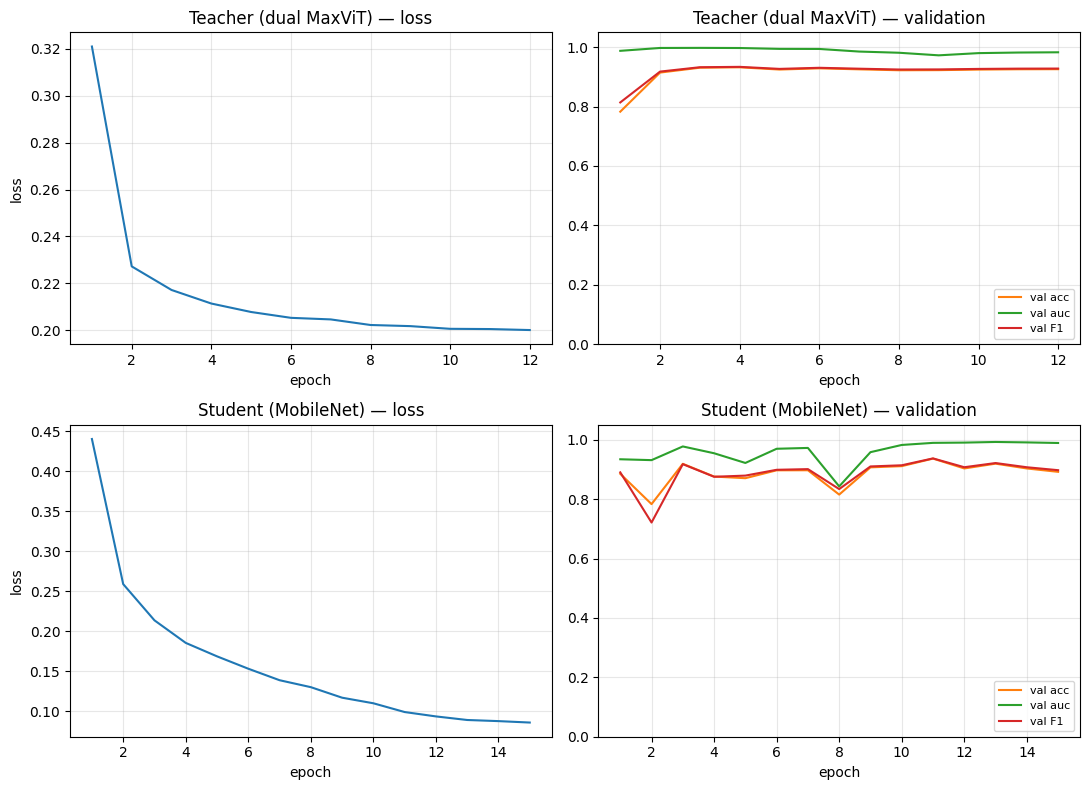

  model      acc      auc       f1
Teacher 0.930933 0.997664 0.932550
Student 0.919269 0.992312 0.921356


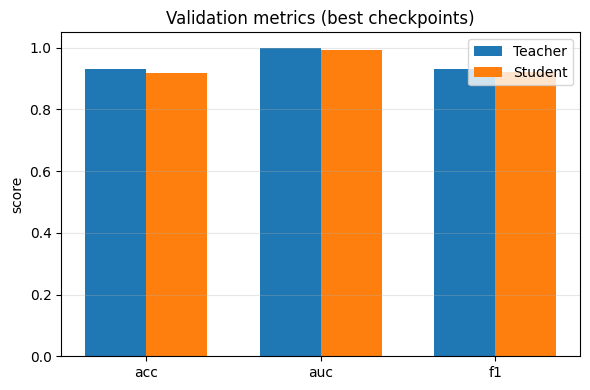

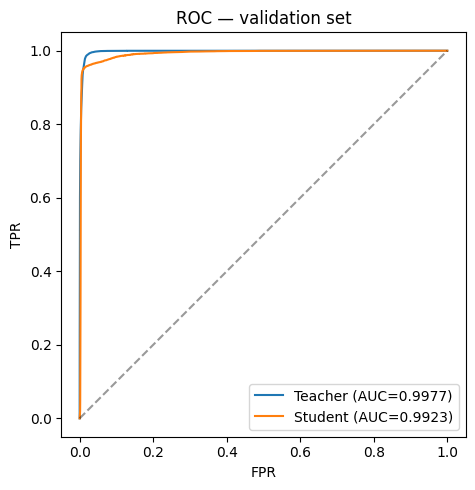

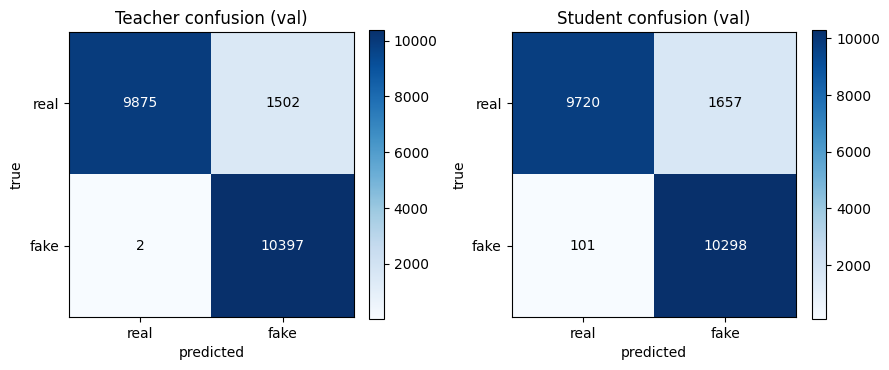

Saved figures to /content/outputs


In [30]:
# Training curves + teacher vs student on validation (best checkpoints)

def plot_history_panel(ax_loss, ax_metrics, hist: dict, title: str):
    epochs = range(1, len(hist["train_loss"]) + 1)
    ax_loss.plot(epochs, hist["train_loss"], label="train loss", color="C0")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("loss")
    ax_loss.set_title(f"{title} — loss")
    ax_loss.grid(True, alpha=0.3)

    ax_metrics.plot(epochs, hist["val_acc"], label="val acc", color="C1")
    ax_metrics.plot(epochs, hist["val_auc"], label="val auc", color="C2")
    ax_metrics.plot(epochs, hist["val_f1"], label="val F1", color="C3")
    ax_metrics.set_xlabel("epoch")
    ax_metrics.set_ylim(0, 1.05)
    ax_metrics.set_title(f"{title} — validation")
    ax_metrics.legend(loc="lower right", fontsize=8)
    ax_metrics.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_history_panel(axes[0, 0], axes[0, 1], teacher_out["history"], "Teacher (dual MaxViT)")
plot_history_panel(axes[1, 0], axes[1, 1], dist_out["history"], "Student (MobileNet)")
plt.tight_layout()
fig.savefig(OUT_DIR / "training_curves_teacher_student.png", dpi=150, bbox_inches="tight")
plt.show()


@torch.no_grad()
def collect_teacher_probs_labels(model, loader):
    model.eval()
    probs_all, y_all = [], []
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16
    for (rgb, spec), yb in loader:
        rgb = rgb.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        spec = spec.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
            logits = model((rgb, spec))
        p = torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
        probs_all.append(p)
        y_all.append(yb.cpu().numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)


@torch.no_grad()
def collect_student_probs_labels(model, loader):
    model.eval()
    probs_all, y_all = [], []
    amp_dtype = torch.bfloat16 if CFG.use_bf16 else torch.float16
    for (rgb, _), yb in loader:
        rgb = rgb.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        yb = yb.to(DEVICE, non_blocking=True)
        with autocast(device_type="cuda", dtype=amp_dtype, enabled=torch.cuda.is_available()):
            logits = model(rgb)
        p = torch.softmax(logits.float(), dim=1)[:, 1].cpu().numpy()
        probs_all.append(p)
        y_all.append(yb.cpu().numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)


_, dual_val_vis = make_dual_loaders(train_df, val_df, img_size=TEACHER_IMG_SIZE, batch_size=TEACHER_BATCH)

student_vis = StudentDeepfakeNet(
    backbone=STUDENT_BACKBONE,
    dropout=STUDENT_DROPOUT,
    img_size=TEACHER_IMG_SIZE,
).to(DEVICE, memory_format=torch.channels_last)
student_vis.load_state_dict(dist_out["best_state"])
student_vis.eval()

pt_teacher, yt = collect_teacher_probs_labels(teacher_loaded, dual_val_vis)
ps_student, ys = collect_student_probs_labels(student_vis, dual_val_vis)
assert np.array_equal(yt, ys)

metrics_tbl = pd.DataFrame([
    {
        "model": "Teacher",
        "acc": accuracy_score(yt, (pt_teacher >= 0.5).astype(int)),
        "auc": roc_auc_score(yt, pt_teacher),
        "f1": f1_score(yt, (pt_teacher >= 0.5).astype(int)),
    },
    {
        "model": "Student",
        "acc": accuracy_score(ys, (ps_student >= 0.5).astype(int)),
        "auc": roc_auc_score(ys, ps_student),
        "f1": f1_score(ys, (ps_student >= 0.5).astype(int)),
    },
])
print(metrics_tbl.to_string(index=False))


fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
w = 0.35
vals_t = [metrics_tbl.loc[0, "acc"], metrics_tbl.loc[0, "auc"], metrics_tbl.loc[0, "f1"]]
vals_s = [metrics_tbl.loc[1, "acc"], metrics_tbl.loc[1, "auc"], metrics_tbl.loc[1, "f1"]]
ax.bar(x - w / 2, vals_t, w, label="Teacher")
ax.bar(x + w / 2, vals_s, w, label="Student")
ax.set_xticks(x)
ax.set_xticklabels(["acc", "auc", "f1"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Validation metrics (best checkpoints)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "teacher_vs_student_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()


auc_t = metrics_tbl.loc[0, "auc"]
auc_s = metrics_tbl.loc[1, "auc"]
fig, ax = plt.subplots(figsize=(6, 5))
fpr_t, tpr_t, _ = roc_curve(yt, pt_teacher)
fpr_s, tpr_s, _ = roc_curve(ys, ps_student)
ax.plot(fpr_t, tpr_t, label=f"Teacher (AUC={auc_t:.4f})")
ax.plot(fpr_s, tpr_s, label=f"Student (AUC={auc_s:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC — validation set")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(OUT_DIR / "teacher_vs_student_roc.png", dpi=150, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, name, probs in (
    (axes[0], "Teacher", pt_teacher),
    (axes[1], "Student", ps_student),
):
    pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(yt, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} confusion (val)")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["real", "fake"])
    ax.set_yticklabels(["real", "fake"])
    thr = cm.max() / 2 if cm.max() > 0 else 1
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="black" if cm[i, j] < thr else "white")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(OUT_DIR / "teacher_vs_student_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figures to", OUT_DIR.resolve())



In [31]:
# # Disconnect runtime
# from google.colab import runtime
# runtime.unassign()